# Random Forest para clasificar dígitos escritos con `sklearn.datasets.load_digits`



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

## 1. Cargar y conocer el dataset

`digits` contiene imágenes de dígitos escritos a mano. Cada imagen tiene 8 × 8 píxeles, por lo que cada observación queda representada mediante 64 características numéricas. La variable objetivo contiene las clases 0 a 9.

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print(f"Número de muestras: {X.shape[0]}")
print(f"Número de características: {X.shape[1]}")
print(f"Clases: {np.unique(y)}")

Número de muestras: 1797
Número de características: 64
Clases: [0 1 2 3 4 5 6 7 8 9]


## 2. Separación 80/20

Se separa el 80 % de los datos para entrenamiento y el 20 % para prueba. Se utiliza `stratify=y` para conservar aproximadamente la misma proporción de las 10 clases en ambos grupos.

El conjunto de prueba queda reservado y **no participa en la selección de hiperparámetros**. La selección se realiza exclusivamente sobre el conjunto de entrenamiento mediante validación cruzada estratificada de 4 folds.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 1437 muestras
Prueba: 360 muestras


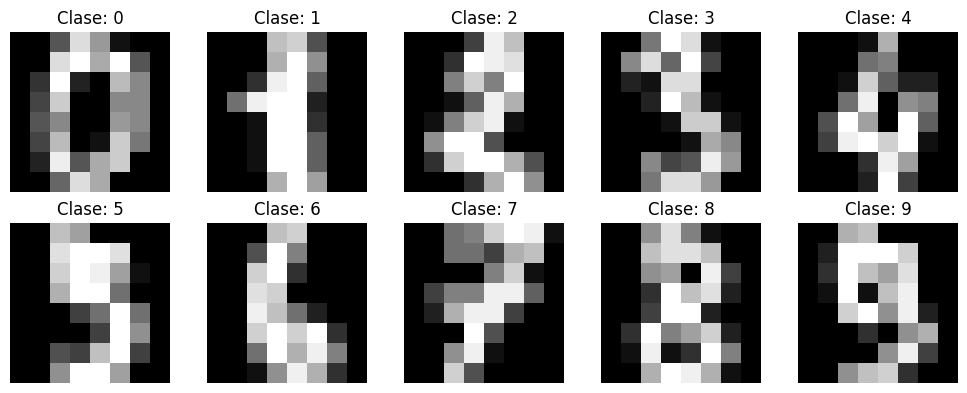

In [4]:
# Visualización de algunos ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, imagen, etiqueta in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Clase: {etiqueta}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Estrategia de poda con `ccp_alpha`

El parámetro `ccp_alpha` controla la **poda por costo-complejidad mínima**. Con `ccp_alpha=0` no se realiza esta poda. Al aumentar `ccp_alpha`, se favorecen subárboles más simples y se eliminan divisiones que aportan poca reducción de impureza.

Siguiendo la idea del cuaderno de referencia, primero se obtiene la ruta de poda de un árbol mediante `cost_complexity_pruning_path`. Esto permite observar los valores de `ccp_alpha` que producen cambios en la complejidad del árbol.

En Random Forest, el mismo `ccp_alpha` se aplica a cada árbol base. En este trabajo, `ccp_alpha` será evaluado junto con `max_depth`, porque ambos parámetros controlan la complejidad, pero de maneras diferentes: `max_depth` limita directamente la profundidad y `ccp_alpha` elimina ramas poco útiles después del crecimiento del árbol.

In [5]:
arbol_referencia = DecisionTreeClassifier(random_state=RANDOM_STATE)
ruta_poda = arbol_referencia.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = ruta_poda.ccp_alphas[:-1]
impurezas = ruta_poda.impurities[:-1]

print(f"Cantidad de valores de alpha en la ruta: {len(ccp_alphas)}")
print(f"Primeros valores: {ccp_alphas[:10]}")

Cantidad de valores de alpha en la ruta: 122
Primeros valores: [0.         0.00068816 0.00069589 0.00069589 0.00069589 0.00069589
 0.00069589 0.00069589 0.00069589 0.00069589]


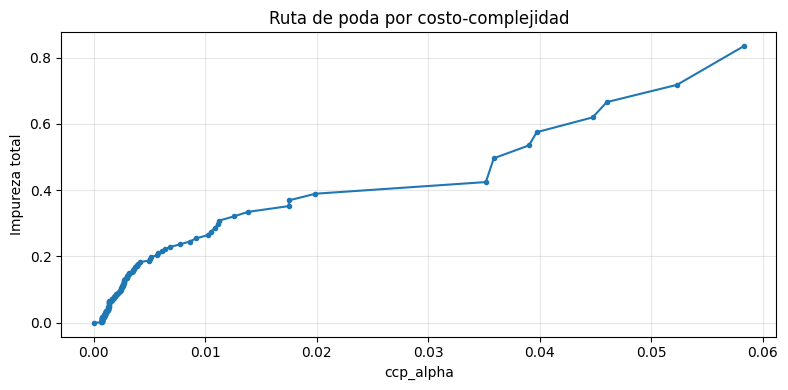

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ccp_alphas, impurezas, marker="o", markersize=3)
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Impureza total")
ax.set_title("Ruta de poda por costo-complejidad")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Validación cruzada de 4 folds

Se utiliza `StratifiedKFold` con `n_splits=4`. En cada configuración se calculan cuatro indicadores:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision macro:** promedio de la precisión de las 10 clases.
- **Recall macro:** promedio del recall de las 10 clases.
- **F1 macro:** promedio del F1 de las 10 clases.

Como el dataset está compuesto por 10 clases, el F1 macro permite valorar el comportamiento del modelo considerando cada dígito con el mismo peso.

In [7]:
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE
)

def evaluar_modelo(modelo):
    resultados = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision_macro",
            "recall": "recall_macro",
            "f1": "f1_macro"
        },
        return_train_score=True,
        n_jobs=-1
    )

    return {
        "accuracy_cv": resultados["test_accuracy"].mean(),
        "precision_cv": resultados["test_precision"].mean(),
        "recall_cv": resultados["test_recall"].mean(),
        "f1_cv": resultados["test_f1"].mean(),
        "f1_std": resultados["test_f1"].std(),
        "accuracy_train": resultados["train_accuracy"].mean(),
        "brecha_accuracy": (
            resultados["train_accuracy"].mean()
            - resultados["test_accuracy"].mean()
        )
    }

## 5. Modelo base sin poda

Primero se crea una referencia con Random Forest sin limitar la profundidad y sin poda (`ccp_alpha=0`). El objetivo no es elegirlo como modelo final, sino tener un punto de comparación para comprobar el efecto de controlar la complejidad.

In [8]:
modelo_base = RandomForestClassifier(
    n_estimators=60,
    max_depth=None,
    ccp_alpha=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

resultado_base = evaluar_modelo(modelo_base)
pd.DataFrame([resultado_base], index=["Modelo base"])

,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_std,accuracy_train,brecha_accuracy
Modelo base,0.969384,0.97,0.969218,0.969139,0.004112,1.0,0.030616


## 6. Búsqueda conjunta de `max_depth` y `ccp_alpha`

Para no hacer una búsqueda excesivamente grande, primero se explora una zona razonable de profundidades y valores de poda. Se mantienen **60 árboles** en esta etapa, porque después se estudiará por separado cuál es el número mínimo de árboles necesario.

La selección se hace principalmente mediante **F1 macro promedio en los 4 folds**. En caso de resultados prácticamente iguales, se privilegia la configuración que genera árboles más pequeños.

In [9]:
profundidades = [9, 10, 11, 12, 13, 14]
alphas = [0.0, 0.0007, 0.0010, 0.0013, 0.0015, 0.0020]

resultados_complejidad = []

for profundidad in profundidades:
    for alpha in alphas:
        modelo = RandomForestClassifier(
            n_estimators=60,
            max_depth=profundidad,
            ccp_alpha=alpha,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        resultado = evaluar_modelo(modelo)
        resultados_complejidad.append({
            "max_depth": profundidad,
            "ccp_alpha": alpha,
            **resultado
        })

resultados_complejidad = pd.DataFrame(resultados_complejidad)
resultados_complejidad.sort_values(
    ["f1_cv", "accuracy_cv"],
    ascending=False
).head(10)

,max_depth,ccp_alpha,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_std,accuracy_train,brecha_accuracy
21,12,0.0013,0.973559,0.974341,0.973502,0.973485,0.004189,1.0,0.026441
22,12,0.0015,0.973559,0.974341,0.973502,0.973485,0.004189,1.0,0.026441
18,12,0.0000,0.972863,0.973621,0.972808,0.972777,0.004602,1.0,0.027137
20,12,0.0010,0.972863,0.973689,0.972789,0.972754,0.006084,1.0,0.027137
19,12,0.0007,0.972166,0.972965,0.972132,0.972073,0.003424,1.0,0.027834
32,14,0.0010,0.971472,0.972284,0.971322,0.971302,0.004166,1.0,0.028528
0,9,0.0000,0.970769,0.971582,0.970785,0.970608,0.003071,1.0,0.029231
26,13,0.0010,0.970771,0.971340,0.970667,0.970575,0.005096,1.0,0.029229
30,14,0.0000,0.970773,0.971465,0.970627,0.970571,0.002460,1.0,0.029227
13,11,0.0007,0.970077,0.970801,0.970088,0.969958,0.003121,1.0,0.029923


### Selección de profundidad y poda

En la búsqueda aparece como zona más favorable `max_depth=12` con `ccp_alpha` alrededor de 0.0013–0.0015. Los dos valores presentan el mismo rendimiento de validación con la semilla usada. Se selecciona **`ccp_alpha=0.0015`** porque, al ajustar el bosque final, produce árboles ligeramente más pequeños que 0.0013 manteniendo el rendimiento.

In [10]:
max_depth_final = 12
ccp_alpha_final = 0.0015
n_estimators_inicial = 60

modelo_complejidad = RandomForestClassifier(
    n_estimators=n_estimators_inicial,
    max_depth=max_depth_final,
    ccp_alpha=ccp_alpha_final,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

resultado_complejidad = evaluar_modelo(modelo_complejidad)
pd.DataFrame([resultado_complejidad], index=["Configuración seleccionada"])

,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_std,accuracy_train,brecha_accuracy
Configuración seleccionada,0.973559,0.974341,0.973502,0.973485,0.004189,1.0,0.026441


## 7. Encontrar el número mínimo de árboles

Ahora se mantiene fija la complejidad de cada árbol (`max_depth=12` y `ccp_alpha=0.0015`) y se estudia el efecto de `n_estimators`.

No se escoge automáticamente el máximo rendimiento de la tabla, porque eso podría introducir más árboles de los necesarios. Se utiliza una **regla de una desviación estándar del error (one-standard-error rule)**:

1. Se identifica la configuración con el mejor F1 promedio.
2. Se calcula su error estándar aproximado como `desviación estándar / sqrt(4)`.
3. Se consideran aceptables las configuraciones cuyo F1 esté dentro de ese margen respecto al mejor valor.
4. Entre ellas se elige el **menor número de árboles**.

Esta regla favorece un modelo más sencillo cuando su rendimiento es estadísticamente cercano al máximo observado en los 4 folds.

In [11]:
numero_arboles = [10, 20, 30, 40, 50, 60, 75, 100]
resultados_arboles = []

for cantidad in numero_arboles:
    modelo = RandomForestClassifier(
        n_estimators=cantidad,
        max_depth=max_depth_final,
        ccp_alpha=ccp_alpha_final,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    resultado = evaluar_modelo(modelo)
    resultados_arboles.append({
        "n_estimators": cantidad,
        **resultado
    })

resultados_arboles = pd.DataFrame(resultados_arboles)
resultados_arboles

,n_estimators,accuracy_cv,precision_cv,recall_cv,f1_cv,f1_std,accuracy_train,brecha_accuracy
0,10,0.942936,0.945083,0.942620,0.942304,0.002956,0.997449,0.054513
1,20,0.963119,0.963930,0.962963,0.962828,0.006321,0.999072,0.035953
2,30,0.965210,0.965875,0.965104,0.964705,0.011175,0.999768,0.034558
3,40,0.965908,0.966726,0.965839,0.965597,0.008137,1.000000,0.034092
4,50,0.970073,0.971054,0.969986,0.969829,0.006044,1.000000,0.029927
5,60,0.973559,0.974341,0.973502,0.973485,0.004189,1.000000,0.026441
6,75,0.974948,0.975659,0.974756,0.974694,0.007245,1.000000,0.025052
7,100,0.973559,0.974103,0.973426,0.973385,0.006494,1.000000,0.026441


In [12]:
best_row = resultados_arboles.loc[resultados_arboles["f1_cv"].idxmax()]
error_estandar = best_row["f1_std"] / np.sqrt(cv.get_n_splits())
limite_f1 = best_row["f1_cv"] - error_estandar

candidatos_simples = resultados_arboles[
    resultados_arboles["f1_cv"] >= limite_f1
].sort_values("n_estimators")

n_estimators_final = int(candidatos_simples.iloc[0]["n_estimators"])

print(f"Mejor F1 CV: {best_row['f1_cv']:.4f}")
print(f"Error estándar: {error_estandar:.4f}")
print(f"Límite de aceptación: {limite_f1:.4f}")
print(f"Número mínimo seleccionado: {n_estimators_final} árboles")

Mejor F1 CV: 0.9747
Error estándar: 0.0036
Límite de aceptación: 0.9711
Número mínimo seleccionado: 60 árboles


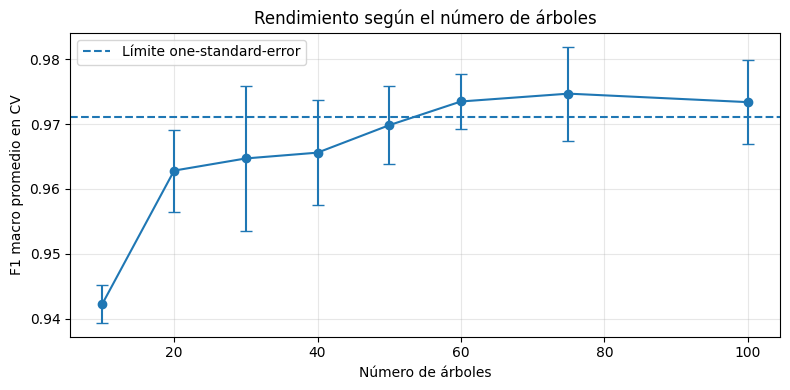

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    resultados_arboles["n_estimators"],
    resultados_arboles["f1_cv"],
    yerr=resultados_arboles["f1_std"],
    marker="o",
    capsize=4
)
ax.axhline(limite_f1, linestyle="--", label="Límite one-standard-error")
ax.set_xlabel("Número de árboles")
ax.set_ylabel("F1 macro promedio en CV")
ax.set_title("Rendimiento según el número de árboles")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Entrenamiento del modelo final

Con la búsqueda anterior, la configuración final es:

- **Número de árboles:** 60
- **Profundidad máxima:** 12
- **`ccp_alpha`:** 0.0015
- **K-fold utilizado para la selección:** 4
- **División inicial:** 80 % entrenamiento y 20 % prueba

La idea de la combinación es controlar la complejidad en dos niveles. `max_depth=12` evita que los árboles crezcan indefinidamente, mientras que `ccp_alpha=0.0015` aplica poda por costo-complejidad. Finalmente, 60 árboles alcanzan un rendimiento de validación cercano al máximo observado con más árboles.

In [14]:
modelo_final = RandomForestClassifier(
    n_estimators=n_estimators_final,
    max_depth=max_depth_final,
    ccp_alpha=ccp_alpha_final,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

In [15]:
accuracy_prueba = accuracy_score(y_test, y_pred)
precision_prueba = precision_score(y_test, y_pred, average="macro")
recall_prueba = recall_score(y_test, y_pred, average="macro")
f1_prueba = f1_score(y_test, y_pred, average="macro")
accuracy_entrenamiento = modelo_final.score(X_train, y_train)

metricas_finales = pd.DataFrame({
    "Indicador": [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Prueba": [
        accuracy_prueba,
        precision_prueba,
        recall_prueba,
        f1_prueba
    ]})

print(f"Accuracy entrenamiento: {accuracy_entrenamiento:.4f}")
print(f"Brecha entrenamiento-prueba: {accuracy_entrenamiento - accuracy_prueba:.4f}")
metricas_finales

Accuracy entrenamiento: 1.0000
Brecha entrenamiento-prueba: 0.0361


,Indicador,Prueba
0,Accuracy,0.963889
1,Precision macro,0.965039
2,Recall macro,0.963567
3,F1 macro,0.963710


## 9. Tamaño de los árboles y comprobación del sobreajuste

La siguiente celda permite comprobar la complejidad real del bosque final. Se reporta la profundidad promedio y el número promedio de hojas por árbol.

La brecha entre entrenamiento y prueba no es cero, por lo que no se afirma que el sobreajuste desaparezca. Lo que se busca es **reducir la complejidad innecesaria** y seleccionar los hiperparámetros con validación cruzada, sin usar el conjunto de prueba para decidirlos.

In [16]:
profundidades_finales = [arbol.get_depth() for arbol in modelo_final.estimators_]
hojas_finales = [arbol.get_n_leaves() for arbol in modelo_final.estimators_]

resumen_arboles = pd.DataFrame({
    "Medida": [
        "Profundidad promedio",
        "Profundidad máxima",
        "Hojas promedio",
        "Hojas máximas"
    ],
    "Valor": [
        np.mean(profundidades_finales),
        np.max(profundidades_finales),
        np.mean(hojas_finales),
        np.max(hojas_finales)
    ]
})

resumen_arboles

,Medida,Valor
0,Profundidad promedio,11.416667
1,Profundidad máxima,12.000000
2,Hojas promedio,104.366667
3,Hojas máximas,129.000000


## 10. Reporte de clasificación

Se revisan las métricas por clase. Esto permite detectar si alguna clase presenta un comportamiento claramente peor que las demás.

In [17]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9722    0.9722    0.9722        36
           1     0.8974    0.9722    0.9333        36
           2     1.0000    0.9714    0.9855        35
           3     0.9730    0.9730    0.9730        37
           4     0.9211    0.9722    0.9459        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    0.9722    0.9859        36
           7     0.9474    1.0000    0.9730        36
           8     0.9688    0.8857    0.9254        35
           9     0.9706    0.9167    0.9429        36

    accuracy                         0.9639       360
   macro avg     0.9650    0.9636    0.9637       360
weighted avg     0.9651    0.9639    0.9639       360



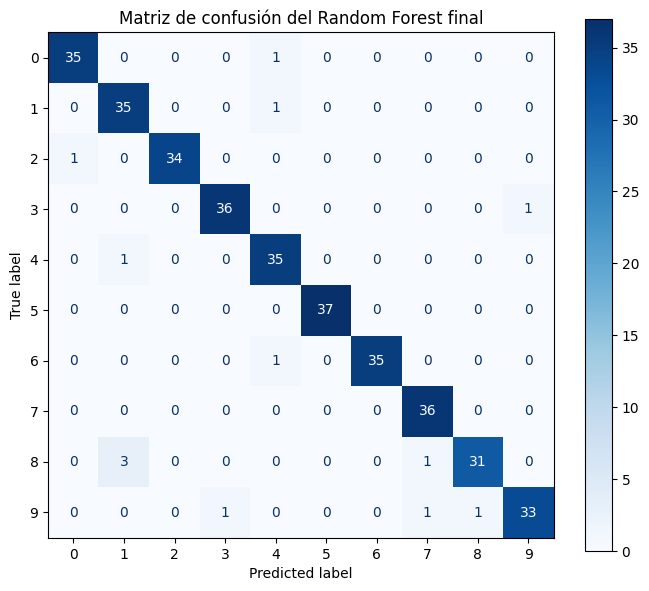

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de confusión del Random Forest final")
plt.tight_layout()
plt.show()

### Resultado de la ejecución de referencia

Con `random_state=42`, la búsqueda de 4 folds seleccionó `max_depth=12` y `ccp_alpha=0.0015`. Aplicando la regla de una desviación estándar sobre el número de árboles, se seleccionaron **60 árboles** como la cantidad mínima dentro del margen de rendimiento aceptable.

En el conjunto de prueba se obtuvo aproximadamente:

| Indicador | Resultado |
|---|---:|
| Accuracy | 96.39 % |
| Precision macro | 96.50 % |
| Recall macro | 96.36 % |
| F1 macro | 96.37 % |

En el ajuste final, la profundidad máxima fue 12, mientras que la profundidad promedio observada de los árboles fue de aproximadamente 11.42 y el número promedio de hojas fue de aproximadamente 104.37. La accuracy de entrenamiento fue 100 %, por lo que la brecha entrenamiento-prueba fue de aproximadamente 3.61 puntos porcentuales. Por eso, el informe no afirma que el sobreajuste desaparezca por completo, sino que la complejidad fue controlada mediante `max_depth`, `ccp_alpha` y la selección del número de árboles por validación cruzada.

## 11. Conclusiones

Con esta partición y semilla reproducible, el procedimiento selecciona un Random Forest de **60 árboles**, con **`max_depth=12`** y **`ccp_alpha=0.0015`**.

La selección se realizó sin tocar el conjunto de prueba: primero se dividieron los datos 80/20 y luego se utilizó validación cruzada estratificada de 4 folds sobre el entrenamiento. La complejidad se controló mediante la combinación de profundidad máxima y poda por costo-complejidad.

El número final de árboles no corresponde necesariamente al máximo rendimiento puntual de la búsqueda. Se escogió el menor número cuyo F1 de validación quedó dentro del margen de la regla de una desviación estándar respecto al mejor resultado. Esto permite reducir el costo del modelo sin alejarse de su mejor rendimiento de validación.

Finalmente, el conjunto de prueba se utilizó una sola vez para estimar el rendimiento de generalización. La brecha entre entrenamiento y prueba se reporta explícitamente para no confundir una accuracy de entrenamiento alta con ausencia de sobreajuste.